## Technique 1: (Overlap Graph : Undirected)

### 1. What are the I/O charactrastics we are trying to find?

Using this technique we are trying to identify the correaltion between saturation of mount point and duration of I/O access across different request sizes. To quantify this correlationship, we calculate the interference factor (IF) for each I/O events and perform characterization of workload based on the pattern of I/O events' IF.

We also identify potential region for I/O performance improvement by identifying the events that are below saturation range for mount points. 


### 2. *How do we find these Characteristics? (methodology)* 

**Graph creation**: We model the I/O traces as a graph where each edge between two I/O events indicates a time overlap between the requests. Since the order of events is irrelevant in this case (i.e., event A overlapping with event B is equivalent to event B overlapping with event A), we treat the graph as undirected. The degree of an event in this graph represents the number of overlapping requests associated with that event. 

**Distributed degree calculation**: Since our traces are large, with millions of nodes, traditional graph representation becomes inefficient, even for basic tasks like computing the degree of a node. To address this, we use DFAnalyzer to segment the traces into multiple time ranges, grouping requests that occur within the same range. This approach improves our computation by: (a) reducing the search space for degree calculations and (b) enabling distributed computation, as events within different time ranges can be processed in parallel.


**IF calculation**: Assuming that all layers in the I/O stack are functioning optimally, I/O requests of the same size directed to the same mount point should take a consistent amount of time to complete. However, when multiple requests are made concurrently, parallel file systems (PFS) can handle these requests concurrently. Yet, if PFS becomes saturated, it may lead to contention ampng these request, causing delays in processing. it can lead to delays in processing these requests. We quantify this delay and refer to it as the Interference Factor for the request.

To calculate the Interference Factor (IF), we first identify the event with the least overlap within each group, based on size and mount point, and use its duration as the reference duration. For each event in the group, we then compute the ratio of its duration to the reference duration, and this ratio is defined as the Interference Factor for that event.


### 3. What do we see? (results)




In [33]:
# Import and load computed data

import pandas as pd
import yaml
import sys

app_name = "deepspeedlow"
cp_dir = "/p/lustre2/pandey2/cp_dir"

with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    dlp_yaml = yaml.safe_load(file)
    app_root = dlp_yaml["app"]
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph import DFGrepInterference, DFGrepWorkflow 
from dfanalyzer.plots import GrepIOPlots

events_obj = DFGrepInterference(app_name=app_name,  cp_dir = cp_dir, existing=True)
size_bins = [
0, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288,
1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728,
268435456, 536870912, 1073741824, float('inf')
]
size_labels = [
'<512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
'64-128KB', '128-256KB', '256-512KB', '512KB-1MB', '1-2MB', '2-4MB', '4-8MB',
'8-16MB', '16-32MB', '32-64MB', '64-128MB', '128-256MB', '256-512MB', '512MB-1GB', '>1GB'
]

degree_bins = [0,2,4,8,16,32,64,float('inf')]
degree_labels = ['<2','2-4','4-8','8-16', '16-32', '32-64','>64']
# degree_bins = [
#     0, 2, 3, 4, 5, 6, 10, 20, float('inf')
# ]
# degree_labels = [
#     '1', '2', '3', '4', '5', '5-10', '10-20', '>20',
# ]

plot = GrepIOPlots()


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns 
def hmap(mp=None, df=None, size_bins=[], size_labels=[], degree_bins=[], degree_labels = []):
    # df= inter.compute()
    if mp:
        df= df[df['mount_point']==mp]
    else:
        mp = "All Mount Points"
    # size_bins, size_labels, degree_bins, degree_labels = binned_category()
    df['size_category'] = pd.cut(df['size'], bins=size_bins, labels=size_labels, right=False)
    df['deg_category'] = pd.cut(df['deg_caller'], bins=degree_bins, labels=degree_labels, right=False)

    df['interference'] = df['val'].astype(float)

    all_combinations = pd.MultiIndex.from_product([df['size_category'].unique(), df['deg_category'].unique()], names=['size_category', 'deg_category'])
    merged = pd.merge(df, pd.DataFrame(index=all_combinations).reset_index(), on=['size_category', 'deg_category'], how='left')
    grouped = merged.groupby(['size_category', 'deg_category']).agg({'interference': 'mean'}).reset_index()

    pivot_table = grouped.pivot(index='size_category', columns='deg_category', values='interference').fillna(0)
    # Create heatmap using seaborn
    plt.figure(figsize=(8, 6))
    # pivot_table = 1/pivot_table
    sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.1f', linewidths=.5)
    plt.title(f'Average Interference Heatmap {mp}')
    plt.xlabel('Degrees')
    plt.ylabel('Sizes')
    plt.show()

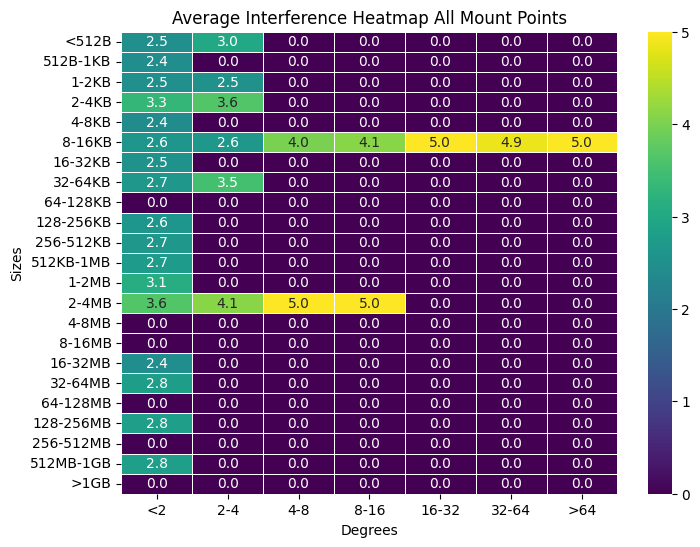

In [73]:

hmap(df=a, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

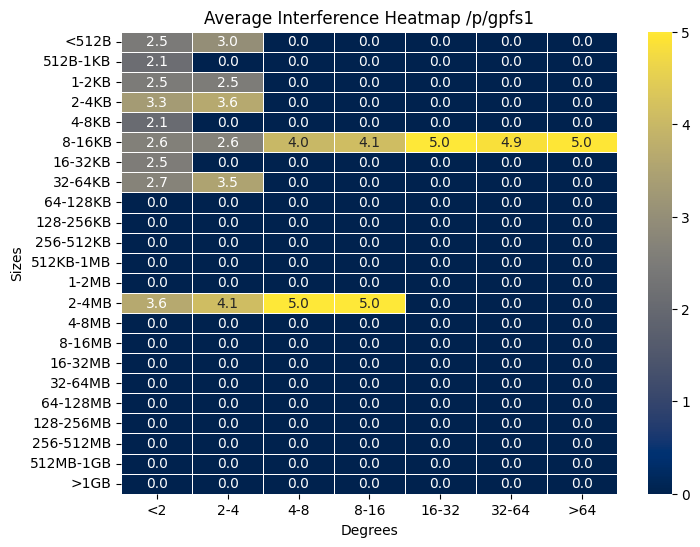

In [68]:

hmap(mp='/p/gpfs1',df=a, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

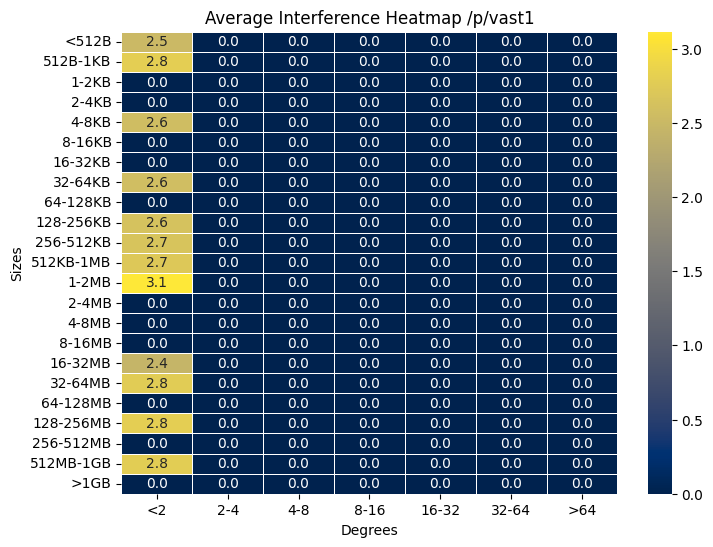

In [69]:

hmap(mp='/p/vast1',df=a, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

In [34]:
a = events_obj.inter.compute()

In [35]:
a

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference
0,read,104999,8192,330642476,330642491,/p/gpfs1,15,11,1,1,8,0.533333
1,read,104999,8192,330642602,330642612,/p/gpfs1,10,11,1,1,8,0.8
2,read,104999,8192,330642699,330642708,/p/gpfs1,9,11,1,1,8,0.888889
3,read,104999,1506,330642793,330642802,/p/gpfs1,9,11,1,1,9,1.0
4,write,104999,33854,330964072,330964253,/p/gpfs1,181,11,1,1,69,0.381215
...,...,...,...,...,...,...,...,...,...,...,...,...
18485,read,104999,1048576,11916942177,11916942344,/p/vast1,167,397,1,1,40,0.239521
18486,read,104999,22,11916942601,11916942607,/p/vast1,6,397,1,1,5,0.833333
18487,read,104999,42,11916942723,11916942728,/p/vast1,5,397,1,1,5,1.0
18488,read,104999,250,11916942806,11916942811,/p/vast1,5,397,1,1,5,1.0


In [48]:
a['interference'] = pd.cut(a['interference'],
                 bins=[0, 0.1, 0.25, 0.75, 1, float('inf')],
                 labels=[5, 4, 3, 2, 1])

In [49]:
a

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference,val
0,read,104999,8192,330642476,330642491,/p/gpfs1,15,11,1,1,8,3,3
1,read,104999,8192,330642602,330642612,/p/gpfs1,10,11,1,1,8,2,2
2,read,104999,8192,330642699,330642708,/p/gpfs1,9,11,1,1,8,2,2
3,read,104999,1506,330642793,330642802,/p/gpfs1,9,11,1,1,9,2,2
4,write,104999,33854,330964072,330964253,/p/gpfs1,181,11,1,1,69,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18485,read,104999,1048576,11916942177,11916942344,/p/vast1,167,397,1,1,40,4,4
18486,read,104999,22,11916942601,11916942607,/p/vast1,6,397,1,1,5,2,2
18487,read,104999,42,11916942723,11916942728,/p/vast1,5,397,1,1,5,2,2
18488,read,104999,250,11916942806,11916942811,/p/vast1,5,397,1,1,5,2,2


In [32]:
a[a['IF'] <.2 ]

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference,val,IF
